# Composition Theorem Comparison — Streaming DP Operator

Compares utility metrics of the Streaming DP operator under three composition theorems:

| Label | Description |
|---|---|
| **DWORK_ANALYTICAL** | Dwork textbook k-fold composition theorem |
| **OPTIMAL_KOV** | KOV optimal composition theorem |
| **ZCDP_LINEAR** | zCDP sequential composition theorem |

**Setup:** T=1000 steps, α=0.5, 10 independent runs per composition strategy.

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [110]:
df = pd.read_csv('data/benchmark_T1000_20260601_100936.csv')

DISPLAY_NAMES = {
    'DWORK_ANALYTICAL': 'Dwork k-fold',
    'OPTIMAL_KOV':      'KOV Optimal',
    'ZCDP_LINEAR':      'zCDP Sequential',
}
COLORS = {
    'DWORK_ANALYTICAL': '#4C72B0',
    'OPTIMAL_KOV':      '#DD8452',
    'ZCDP_LINEAR':      '#55A868',
}

# Separate individual runs from the pre-computed averages (run == -1)
runs_df = df[df['run'] >= 0].copy()
avg_df  = df[df['run'] == -1].copy()

df.head()

,T,alpha,composition,mu,run,l0_mean,l_inf_mean,l1_mean,l2_mean,sec_per_run,eps_round,delta_round,sigma_key,sigma_hist,beta,threshold_quantile,tau_at_last_step
0,1000,0.5,DWORK_ANALYTICAL,0,0,4800.0,4090.0,34652538.0,168588.353625,29261.626475,0.075256,1.031494e-11,257.672209,211.758134,2.481748e-12,6.906614,3981.346002
1,1000,0.5,DWORK_ANALYTICAL,0,1,4809.0,3827.0,34641489.0,168378.621306,29269.110242,0.075256,1.031494e-11,257.672209,211.758134,2.481748e-12,6.906614,3981.346002
2,1000,0.5,DWORK_ANALYTICAL,0,2,4849.0,3989.0,34562402.0,167585.302297,29335.720909,0.075256,1.031494e-11,257.672209,211.758134,2.481748e-12,6.906614,3981.346002
3,1000,0.5,DWORK_ANALYTICAL,0,3,4836.0,3758.0,34668822.0,168426.227120,29267.076253,0.075256,1.031494e-11,257.672209,211.758134,2.481748e-12,6.906614,3981.346002
4,1000,0.5,DWORK_ANALYTICAL,0,4,4820.0,4032.0,34641192.0,168091.236434,29333.816125,0.075256,1.031494e-11,257.672209,211.758134,2.481748e-12,6.906614,3981.346002


## Privacy & Noise Parameters per Composition

Each theorem yields a different per-round privacy budget (ε, δ) and therefore different noise levels.

In [111]:
param_cols = ['composition', 'eps_round', 'delta_round', 'sigma_key', 'sigma_hist', 'tau_at_last_step']
params = avg_df[param_cols].copy()
params['composition'] = params['composition'].map(DISPLAY_NAMES)
params = params.rename(columns={
    'composition':     'Composition',
    'eps_round':       'ε / round',
    'delta_round':     'δ / round',
    'sigma_key':       'σ_key',
    'sigma_hist':      'σ_hist',
    'tau_at_last_step':'τ (last step)',
})
params.set_index('Composition', inplace=True)
params.style.format({
    'ε / round':    '{:.4e}',
    'δ / round':    '{:.4e}',
    'σ_key':        '{:.4f}',
    'σ_hist':       '{:.4f}',
    'τ (last step)':'{:.2f}',
})

,ε / round,δ / round,σ_key,σ_hist,τ (last step)
Composition,,,,,
Dwork k-fold,7.5256e-02,1.0315e-11,257.6722,211.7581,3981.35
KOV Optimal,9.3750e-02,2.0813e-11,204.3559,211.7581,3112.31
zCDP Sequential,6.0635e-01,2.0833e-11,36.8012,211.7581,564.02


## Utility Metrics — Individual Runs (Box Plots)

Each composition has 10 runs. Box plots show the spread.

The four metrics measure different aspects of error in the output histogram:
- **L0** — number of non-zero errors (sparsity)
- **L$\infty$** — maximum absolute error (worst-case bucket)
- **L1** — total absolute error
- **L2** — root-sum-squared error

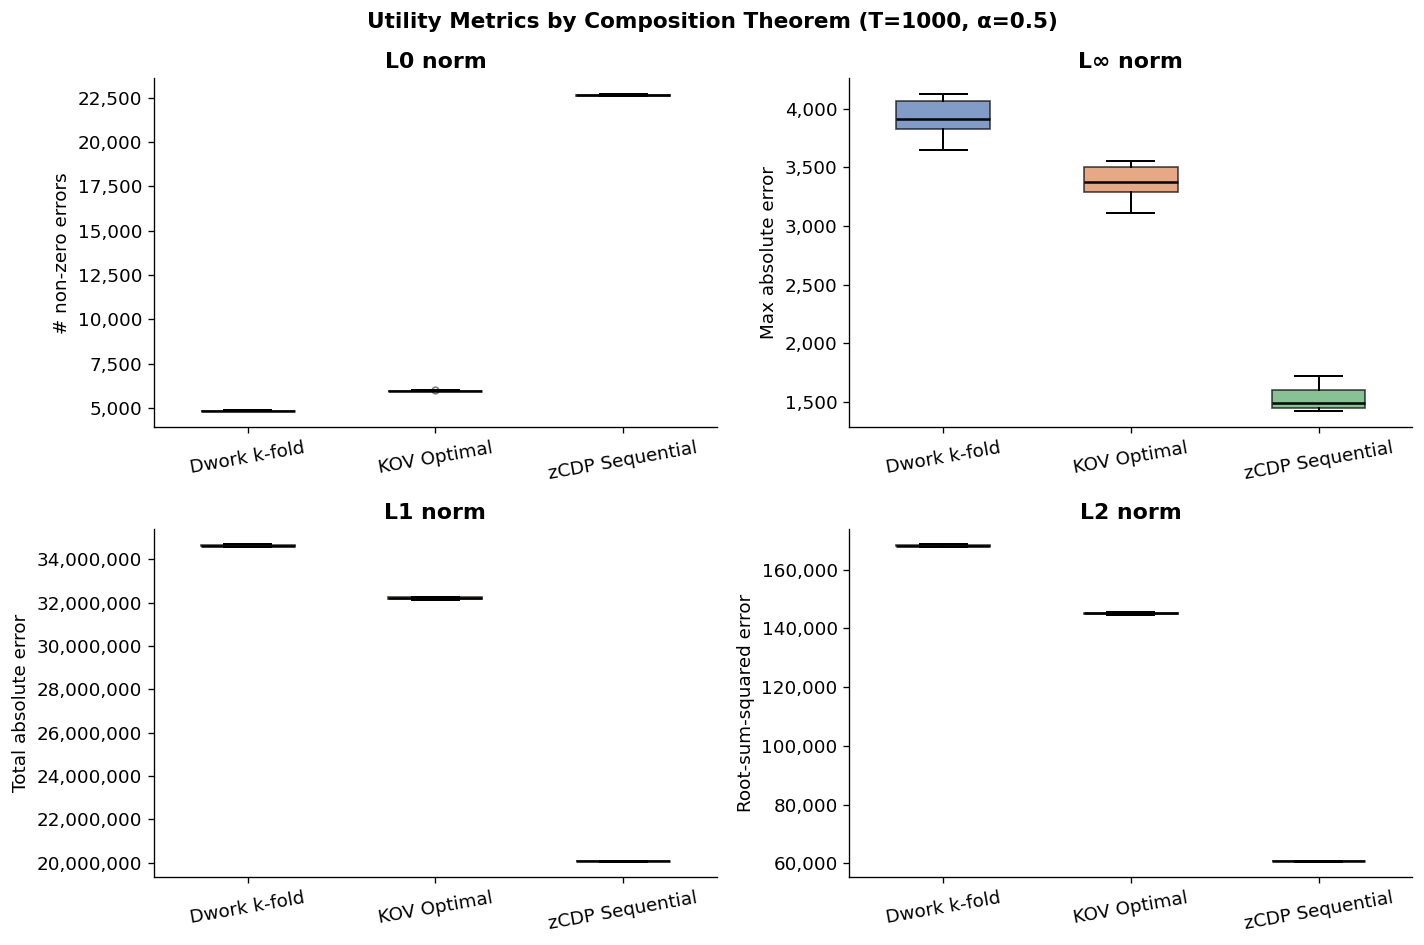

In [112]:
metrics = [
    ('l0_mean',   'L0 norm',  '# non-zero errors'),
    ('l_inf_mean','L∞ norm',  'Max absolute error'),
    ('l1_mean',   'L1 norm',  'Total absolute error'),
    ('l2_mean',   'L2 norm',  'Root-sum-squared error'),
]

compositions = list(DISPLAY_NAMES.keys())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Utility Metrics by Composition Theorem (T=1000, α=0.5)', fontsize=13, fontweight='bold')

for ax, (col, title, ylabel) in zip(axes.flat, metrics):
    data_groups = [runs_df[runs_df['composition'] == c][col].values for c in compositions]
    bp = ax.boxplot(
        data_groups,
        tick_labels=[DISPLAY_NAMES[c] for c in compositions],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        widths=0.5,
    )
    for patch, comp in zip(bp['boxes'], compositions):
        patch.set_facecolor(COLORS[comp])
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='semibold')
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', labelrotation=10)

plt.tight_layout()
plt.savefig('data/composition_boxplots.pdf', bbox_inches='tight')
plt.show()

## Utility Metrics — Averages with Error Bars

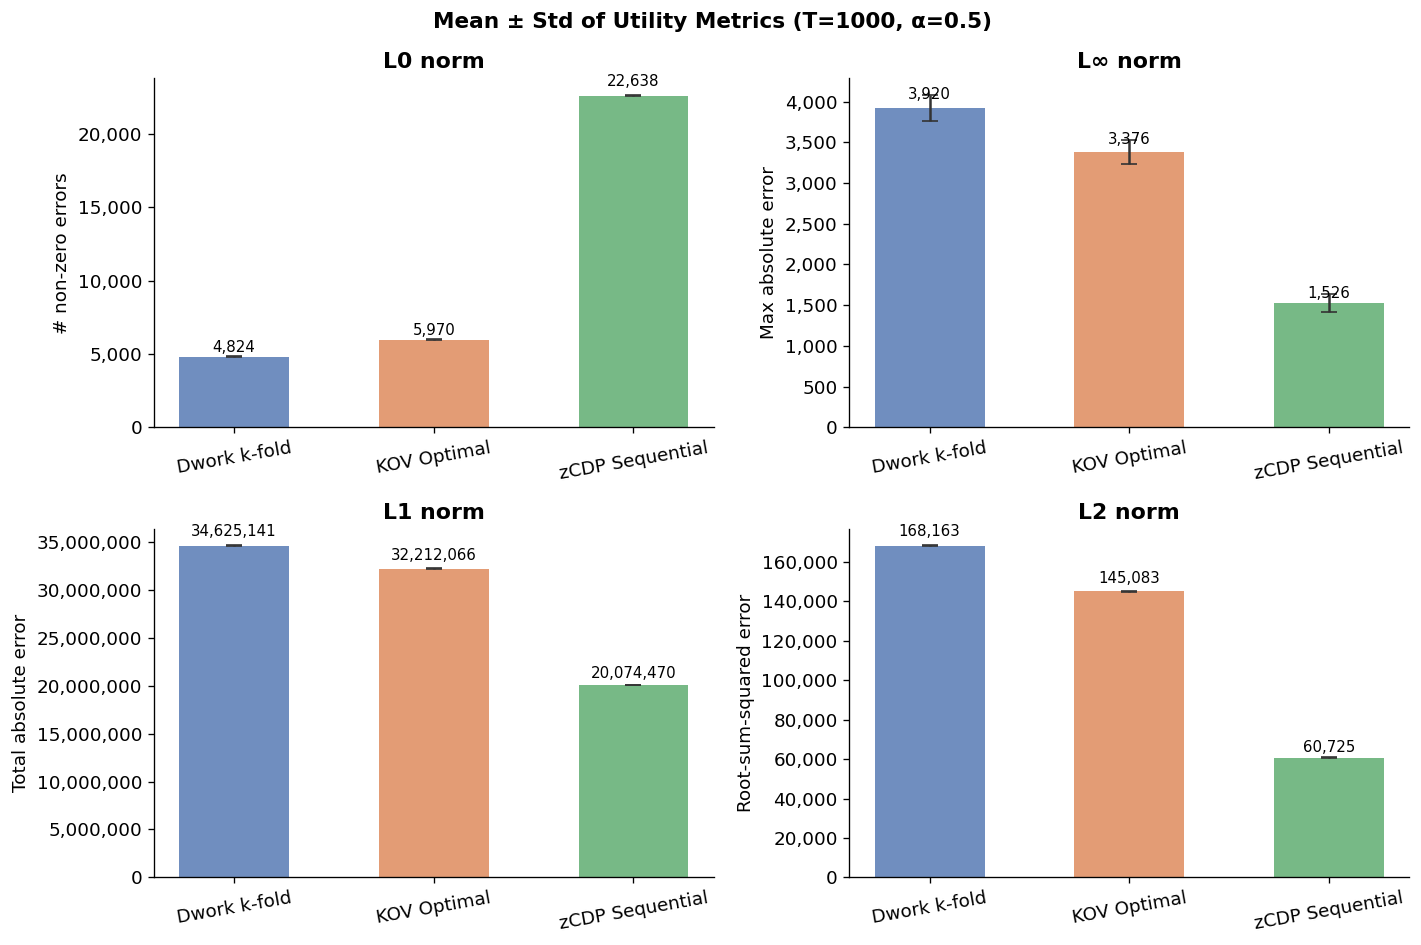

In [113]:
# Compute mean ± std across runs for each composition
stats = runs_df.groupby('composition')[['l0_mean', 'l_inf_mean', 'l1_mean', 'l2_mean']].agg(['mean', 'std'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Mean ± Std of Utility Metrics (T=1000, α=0.5)', fontsize=13, fontweight='bold')

x = np.arange(len(compositions))
w = 0.55

for ax, (col, title, ylabel) in zip(axes.flat, metrics):
    means = [stats.loc[c, (col, 'mean')] for c in compositions]
    stds  = [stats.loc[c, (col, 'std')]  for c in compositions]
    colors = [COLORS[c] for c in compositions]
    bars = ax.bar(x, means, width=w, color=colors, alpha=0.8, yerr=stds,
                  error_kw=dict(ecolor='#333', capsize=5, linewidth=1.5))
    ax.set_title(title, fontweight='semibold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([DISPLAY_NAMES[c] for c in compositions], rotation=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    # Annotate bars with value
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{mean:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/composition_bars.pdf', bbox_inches='tight')
plt.show()

## Relative Change vs Dwork Baseline

Shows how much KOV and zCDP differ from the Dwork textbook baseline.
Direction of improvement depends on the metric:
- **L0 (keys released):** positive = more keys = **better**
- **L∞ / L1 / L2 (error norms):** negative = lower error = **better**


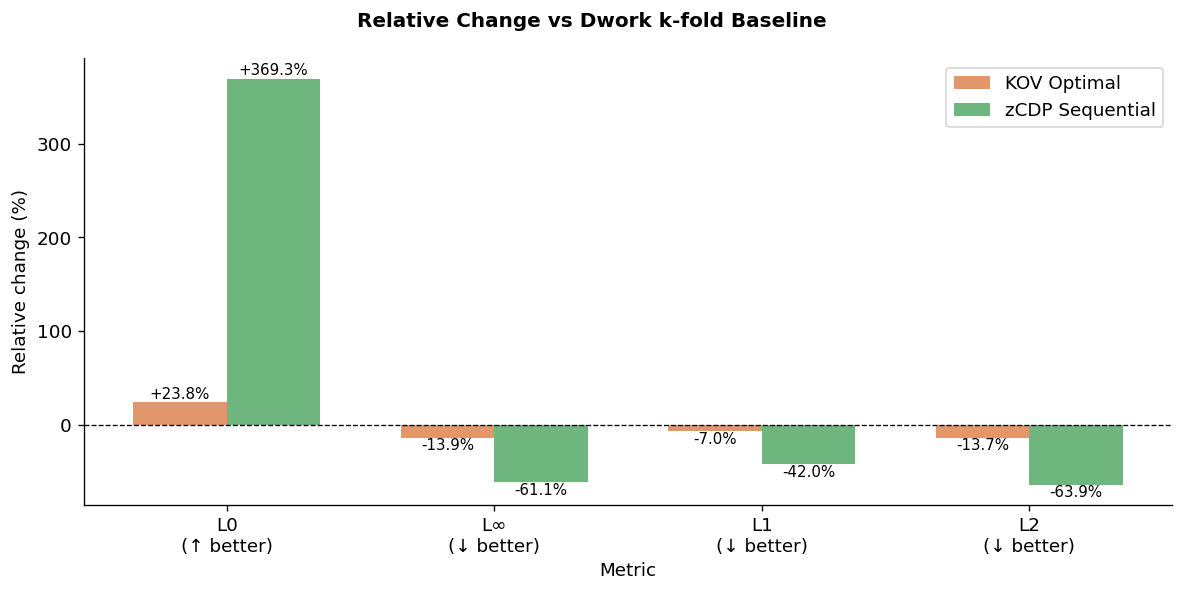

In [114]:
baseline = 'DWORK_ANALYTICAL'
metric_cols = ['l0_mean', 'l_inf_mean', 'l1_mean', 'l2_mean']
metric_labels = ['L0\n(↑ better)', 'L∞\n(↓ better)', 'L1\n(↓ better)', 'L2\n(↓ better)']

base_means = stats.loc[baseline, [(c, 'mean') for c in metric_cols]].values

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Relative Change vs Dwork k-fold Baseline', fontsize=12, fontweight='bold')

comparators = [c for c in compositions if c != baseline]
n_metrics = len(metric_cols)
x = np.arange(n_metrics)
bar_width = 0.35
offsets = np.linspace(-(len(comparators)-1)*bar_width/2, (len(comparators)-1)*bar_width/2, len(comparators))

for offset, comp in zip(offsets, comparators):
    comp_means = stats.loc[comp, [(c, 'mean') for c in metric_cols]].values
    rel_change = (comp_means - base_means) / base_means * 100
    bars = ax.bar(x + offset, rel_change, width=bar_width,
                  label=DISPLAY_NAMES[comp], color=COLORS[comp], alpha=0.85)
    for bar, val in zip(bars, rel_change):
        va = 'bottom' if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (0.5 if val >= 0 else -0.5),
                f'{val:+.1f}%', ha='center', va=va, fontsize=9)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Relative change (%)')
ax.set_xlabel('Metric')
ax.legend()
plt.tight_layout()
plt.savefig('data/composition_relative.pdf', bbox_inches='tight')
plt.show()


## Noise Level vs Utility Trade-off

Higher noise (σ_key) → larger privacy budget per round → tighter composition → potentially better utility. This scatter shows where each theorem lands on the σ_key vs L2 error plane.

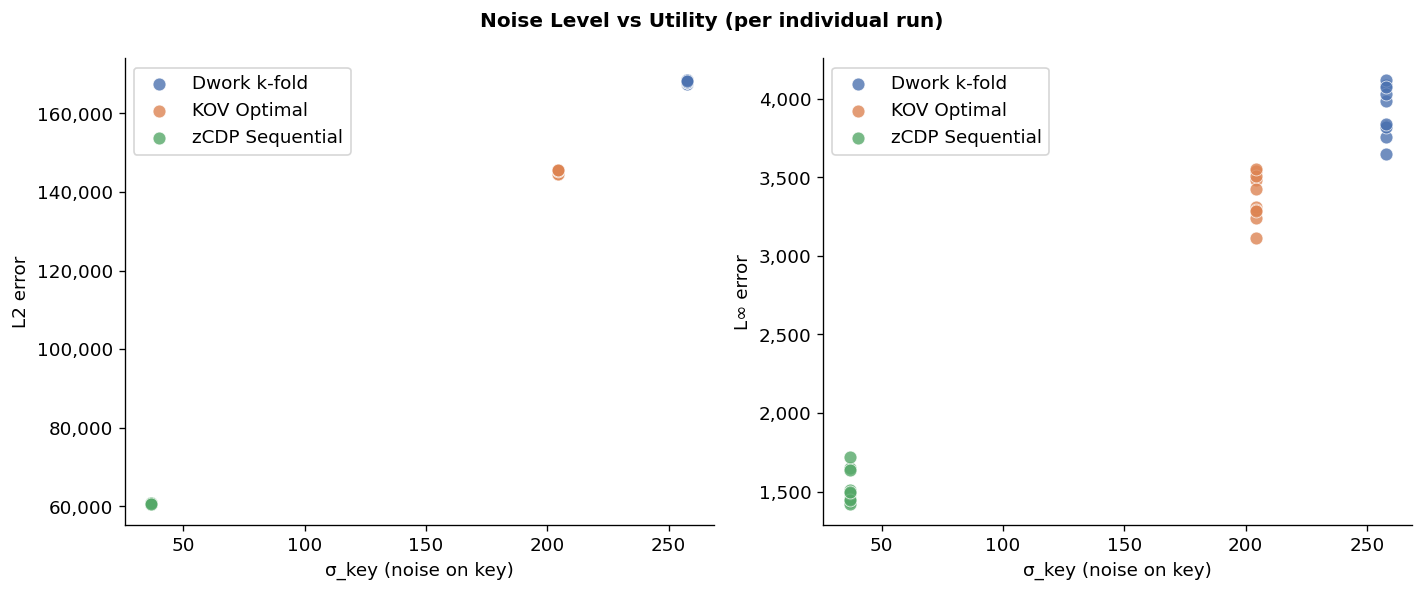

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Noise Level vs Utility (per individual run)', fontsize=12, fontweight='bold')

pairs = [
    ('sigma_key', 'l2_mean',   'σ_key (noise on key)',  'L2 error', axes[0]),
    ('sigma_key', 'l_inf_mean','σ_key (noise on key)',  'L∞ error', axes[1]),
]

for xcol, ycol, xlabel, ylabel, ax in pairs:
    for comp in compositions:
        sub = runs_df[runs_df['composition'] == comp]
        ax.scatter(sub[xcol], sub[ycol],
                   label=DISPLAY_NAMES[comp], color=COLORS[comp],
                   s=60, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend()

plt.tight_layout()
plt.savefig('data/composition_scatter.pdf', bbox_inches='tight')
plt.show()

## Runtime Comparison

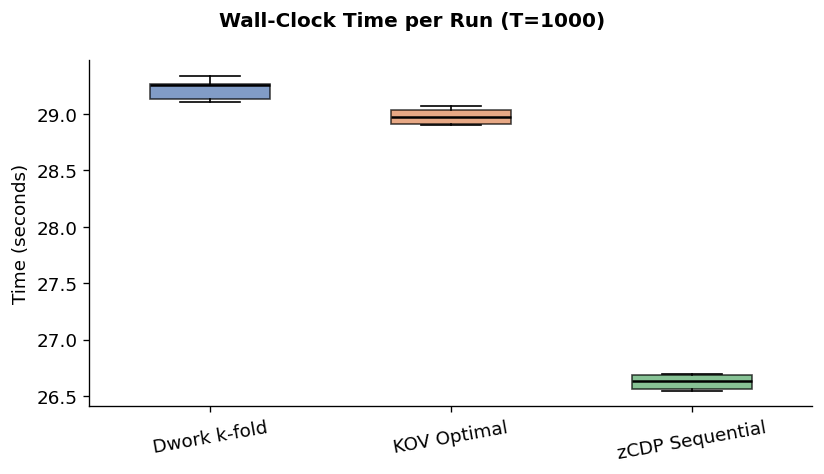

In [116]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('Wall-Clock Time per Run (T=1000)', fontsize=12, fontweight='bold')

data_groups = [runs_df[runs_df['composition'] == c]['sec_per_run'].values / 1000 for c in compositions]
bp = ax.boxplot(
    data_groups,
    tick_labels=[DISPLAY_NAMES[c] for c in compositions],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    widths=0.5,
)
for patch, comp in zip(bp['boxes'], compositions):
    patch.set_facecolor(COLORS[comp])
    patch.set_alpha(0.7)

ax.set_ylabel('Time (seconds)')
ax.tick_params(axis='x', labelrotation=10)
plt.tight_layout()
plt.savefig('data/composition_runtime.pdf', bbox_inches='tight')
plt.show()

## Summary Table

In [117]:
summary = runs_df.groupby('composition').agg(
    L0_mean=('l0_mean',   'mean'),
    L0_std= ('l0_mean',   'std'),
    Linf_mean=('l_inf_mean', 'mean'),
    Linf_std= ('l_inf_mean', 'std'),
    L1_mean=('l1_mean',   'mean'),
    L1_std= ('l1_mean',   'std'),
    L2_mean=('l2_mean',   'mean'),
    L2_std= ('l2_mean',   'std'),
    time_mean=('sec_per_run', 'mean'),
).reset_index()

summary['composition'] = summary['composition'].map(DISPLAY_NAMES)
summary = summary.set_index('composition')

best_props  = 'background-color: #198754; color: white; font-weight: bold'
worst_props = 'background-color: #dc3545; color: white; font-weight: bold'
error_cols  = ['Linf_mean', 'L1_mean', 'L2_mean']  # lower is better

summary.style.format({
    'L0_mean':   '{:,.0f}', 'L0_std':   '{:,.0f}',
    'Linf_mean': '{:,.0f}', 'Linf_std': '{:,.0f}',
    'L1_mean':   '{:,.0f}', 'L1_std':   '{:,.0f}',
    'L2_mean':   '{:,.1f}', 'L2_std':   '{:,.1f}',
    'time_mean': '{:,.0f} ms',
}).highlight_max(subset=['L0_mean'], props=best_props)\
  .highlight_min(subset=['L0_mean'], props=worst_props)\
  .highlight_min(subset=error_cols, props=best_props)\
  .highlight_max(subset=error_cols, props=worst_props)


,L0_mean,L0_std,Linf_mean,Linf_std,L1_mean,L1_std,L2_mean,L2_std,time_mean
composition,,,,,,,,,
Dwork k-fold,"4,824",17,"3,920",162,"34,625,141","41,121","168,163.4",307.2,"29,222 ms"
KOV Optimal,"5,970",27,"3,376",148,"32,212,066","44,387","145,083.4",336.4,"28,981 ms"
zCDP Sequential,"22,638",40,"1,526",105,"20,074,470","10,271","60,724.6",100.0,"26,628 ms"


---
## Comparison Against Paper (Table 1)

Reference values from **Table 1** of the paper (ε = 6, δ = 10⁻⁹, T = 1000 micro-batches).

| Method | Keys (L0) | ℓ∞ | ℓ1 | ℓ2 |
|---|---|---|---|---|
| DP-SQLP | 22,280 | 1,563 | 19,395,721 | 58,237 |
| Baseline 1 | 0 | 25,497 | 59,052,062 | 594,382 |
| Baseline 2 | 0 | 25,497 | 59,052,062 | 594,382 |

Our benchmark runs the same streaming DP operator with three different composition theorems.
The table and plots below overlay our per-theorem averages against the paper reference.

In [118]:
# Paper reference values (T=1000, ε=6, δ=1e-9)
paper_data = {
    'Method':    ['DP-SQLP (paper)', 'Baseline 1 (paper)', 'Baseline 2 (paper)'],
    'l0_mean':   [22_280,  435,          191],
    'l_inf_mean':[1_563,   25_497,     25_497],
    'l1_mean':   [19_395_721, 59_052_062, 59_052_062],
    'l2_mean':   [58_237,  594_382,    594_382],
}
paper_df = pd.DataFrame(paper_data).set_index('Method')

our_avg = avg_df[['composition', 'l0_mean', 'l_inf_mean', 'l1_mean', 'l2_mean']].copy()
our_avg['composition'] = our_avg['composition'].map(DISPLAY_NAMES)
our_avg = our_avg.set_index('composition')
our_avg.index.name = 'Method'

combined = pd.concat([our_avg, paper_df])

best_props  = 'background-color: #198754; color: white; font-weight: bold'
worst_props = 'background-color: #dc3545; color: white; font-weight: bold'
error_cols  = ['l_inf_mean', 'l1_mean', 'l2_mean']  # lower is better

combined.style.format({
    'l0_mean':   '{:,.0f}',
    'l_inf_mean':'{:,.0f}',
    'l1_mean':   '{:,.0f}',
    'l2_mean':   '{:,.1f}',
}).set_table_styles([{
    'selector': 'thead th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]
}]).highlight_max(subset=['l0_mean'], props=best_props)\
   .highlight_min(subset=['l0_mean'], props=worst_props)\
   .highlight_min(subset=error_cols, props=best_props)\
   .highlight_max(subset=error_cols, props=worst_props)


,l0_mean,l_inf_mean,l1_mean,l2_mean
Method,,,,
Dwork k-fold,"4,824","3,920","34,625,141","168,163.4"
KOV Optimal,"5,970","3,376","32,212,066","145,083.4"
zCDP Sequential,"22,638","1,526","20,074,470","60,724.6"
DP-SQLP (paper),"22,280","1,563","19,395,721","58,237.0"
Baseline 1 (paper),435,"25,497","59,052,062","594,382.0"
Baseline 2 (paper),191,"25,497","59,052,062","594,382.0"


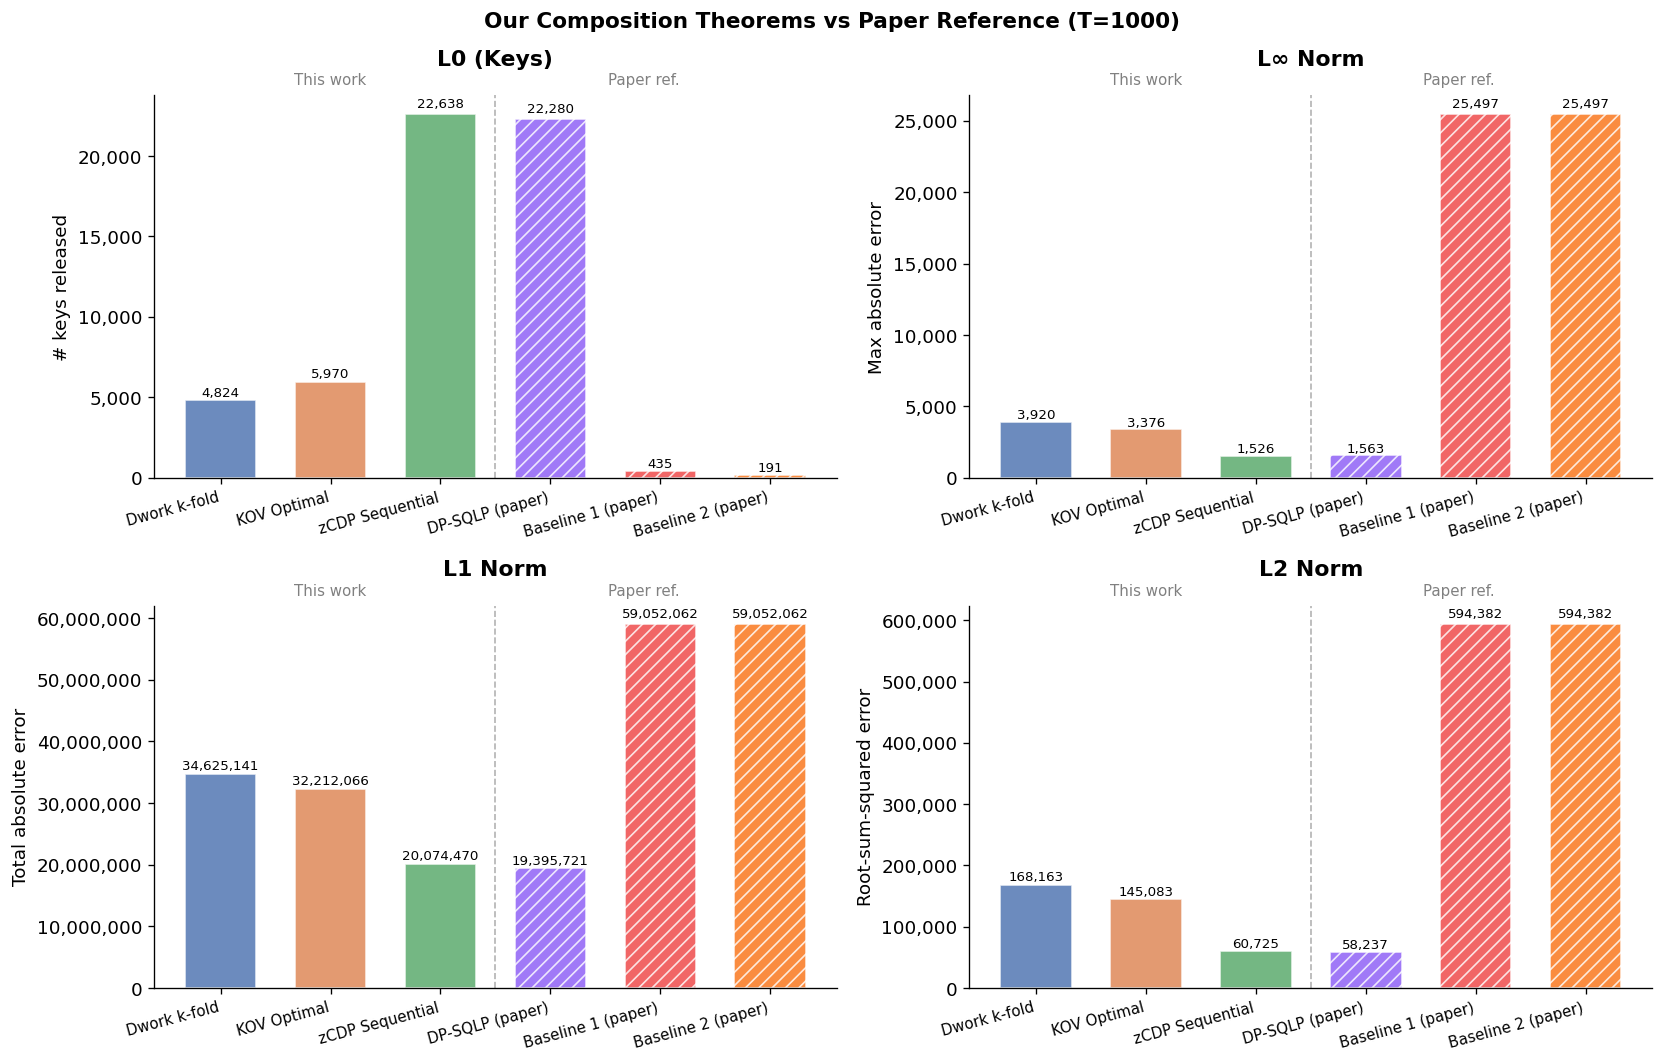

In [119]:
from matplotlib.transforms import blended_transform_factory

ALL_METHODS = list(DISPLAY_NAMES.values()) + ['DP-SQLP (paper)', 'Baseline 1 (paper)', 'Baseline 2 (paper)']
ALL_COLORS  = [
    COLORS['DWORK_ANALYTICAL'], COLORS['OPTIMAL_KOV'], COLORS['ZCDP_LINEAR'],
    '#8B5CF6', '#EF4444', '#F97316',
]
HATCHES = ['', '', '', '///', '///', '///']

metric_info = [
    ('l0_mean',    'L0 (Keys)',  '# keys released'),
    ('l_inf_mean', 'L∞ Norm',    'Max absolute error'),
    ('l1_mean',    'L1 Norm',    'Total absolute error'),
    ('l2_mean',    'L2 Norm',    'Root-sum-squared error'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Our Composition Theorems vs Paper Reference (T=1000)', fontsize=13, fontweight='bold')

x = np.arange(len(ALL_METHODS))
w = 0.65
MIN_VISIBLE_FRAC = 0.00

for ax, (col, title, ylabel) in zip(axes.flat, metric_info):
    values = np.array(list(our_avg[col].values) + list(paper_df[col].values), dtype=float)
    max_val = values.max()
    # calculate a minimum display height (5% of max) to ensure tiny bars are visible
    floor   = max_val * MIN_VISIBLE_FRAC
    # Display height: real value, but at least `floor` so tiny bars are visible
    display = np.where(values > 0, np.maximum(values, floor), 0.0)

    bars = ax.bar(x, display, width=w, color=ALL_COLORS, alpha=0.82,
                  hatch=HATCHES, edgecolor='white')

    # Vertical divider
    ax.axvline(2.5, color='gray', linewidth=1, linestyle='--', alpha=0.6)
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.0,  1.02, 'This work',  transform=trans, ha='center', fontsize=9,
            color='gray', va='bottom')
    ax.text(3.85, 1.02, 'Paper ref.', transform=trans, ha='center', fontsize=9,
            color='gray', va='bottom')
    ax.set_title(title, fontweight='semibold', pad=18)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(ALL_METHODS, rotation=15, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    # Annotate with the REAL value (not the padded display height)
    for bar, real_val, disp_val in zip(bars, values, display):
        if real_val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, disp_val * 1.01,
                    f'{real_val:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('data/composition_vs_paper.pdf', bbox_inches='tight')
plt.show()


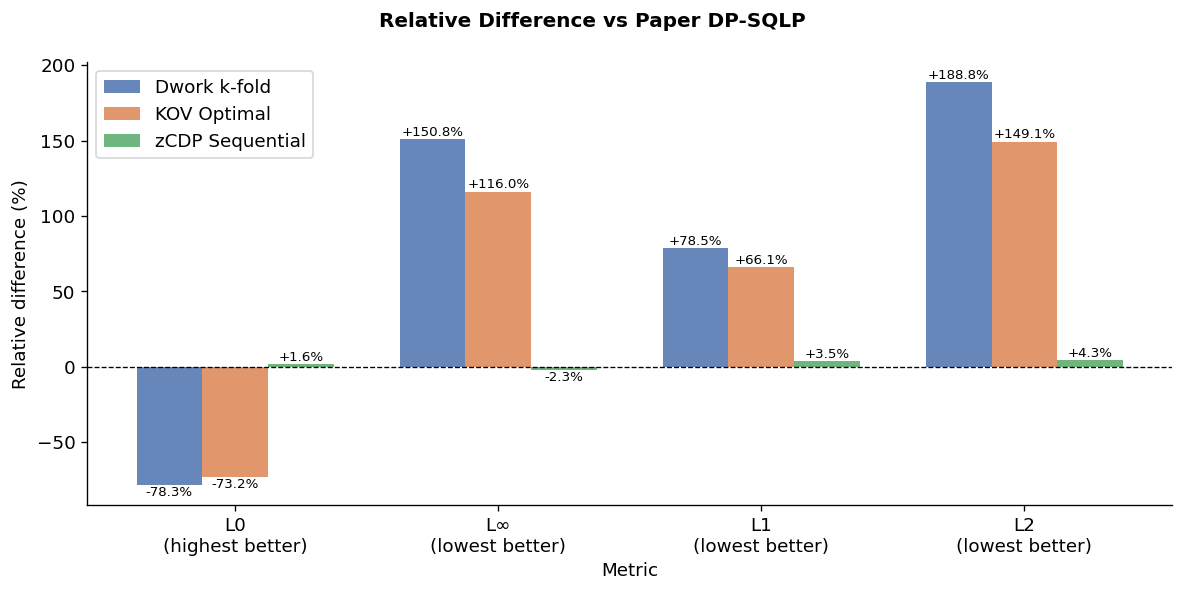

In [120]:
# Relative difference: (our - paper_DPSQLP) / paper_DPSQLP * 100
paper_sqlp = paper_df.loc['DP-SQLP (paper)']

rel_rows = []
for method in our_avg.index:
    row = {'Method': method}
    for col in ['l0_mean', 'l_inf_mean', 'l1_mean', 'l2_mean']:
        ref = paper_sqlp[col]
        val = our_avg.loc[method, col]
        row[col] = (val - ref) / ref * 100 if ref != 0 else float('nan')
    rel_rows.append(row)

rel_df = pd.DataFrame(rel_rows).set_index('Method')

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Relative Difference vs Paper DP-SQLP', fontsize=12, fontweight='bold')

n_methods = len(rel_df)
metric_labels = ['L0\n(highest better)', 'L∞\n(lowest better)', 'L1\n(lowest better)', 'L2\n(lowest better)']
x = np.arange(4)
bar_w = 0.25
offsets = np.linspace(-(n_methods-1)*bar_w/2, (n_methods-1)*bar_w/2, n_methods)

for offset, (method, row) in zip(offsets, rel_df.iterrows()):
    orig_key = {v: k for k, v in DISPLAY_NAMES.items()}[method]
    vals = [row['l0_mean'], row['l_inf_mean'], row['l1_mean'], row['l2_mean']]
    bars = ax.bar(x + offset, vals, width=bar_w, label=method,
                  color=COLORS[orig_key], alpha=0.85)
    for bar, val in zip(bars, vals):
        if not (val != val):  # skip NaN
            va = 'bottom' if val >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + (0.5 if val >= 0 else -0.5),
                    f'{val:+.1f}%', ha='center', va=va, fontsize=8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Relative difference (%)')
ax.set_xlabel('Metric')
ax.legend()
plt.tight_layout()
plt.savefig('data/composition_vs_paper_relative.pdf', bbox_inches='tight')
plt.show()
